In [21]:
# load your dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#loading the dataset
df=pd.read_csv("cognicart/data/raw/supermarket_data.csv")
print("Dataset Loaded Successfully")
print(f"Shape:{df.shape}")
print(f"Rows::{df.shape[0]}")
print(f"Columns:{df.shape[1]}")
print(df.head())


Dataset Loaded Successfully
Shape:(25012, 10)
Rows::25012
Columns:10
   TransactionID Customer_ID        Date DayOfWeek    Month  \
0              1       C0062  2024-01-04  Thursday  January   
1              2       C0062  2024-01-04  Thursday  January   
2              3       C0062  2024-01-04  Thursday  January   
3              4       C0062  2024-01-04  Thursday  January   
4              5       C0062  2024-01-04  Thursday  January   

             Category      Product  Quantity   Price CustomerType  
0              Snacks        Chips         2  255.13  snack_lover  
1           Beverages       Coffee         3   45.32  snack_lover  
2              Snacks      Popcorn         1  223.75  snack_lover  
3           Beverages   Cold Drink         4  461.37  snack_lover  
4  Cooking Essentials  Tomatosauce         3  292.12  snack_lover  


In [23]:
#explore dataset
#see all columns
print("Column Names:")
print(df.columns.tolist())
#see datatyoe of each column
print("Data Types:")
print(df.dtypes)
 #see basic statistics
print("Basic Statistics:")
print(df.describe())
#count unique values
print(f"Unique Customers:{df["Customer_ID"].nunique()}")
print(f"Unique Products:{df["Product"].nunique()}")
print(f"Unique Transactions:{df["Category"].nunique()}")

Column Names:
['TransactionID', 'Customer_ID', 'Date', 'DayOfWeek', 'Month', 'Category', 'Product', 'Quantity', 'Price', 'CustomerType']
Data Types:
TransactionID      int64
Customer_ID       object
Date              object
DayOfWeek         object
Month             object
Category          object
Product           object
Quantity           int64
Price            float64
CustomerType      object
dtype: object
Basic Statistics:
       TransactionID      Quantity         Price
count   25012.000000  25012.000000  25012.000000
mean    12506.500000      3.004598    254.499765
std      7220.486803      1.413315    141.214666
min         1.000000      1.000000     10.030000
25%      6253.750000      2.000000    132.402500
50%     12506.500000      3.000000    253.235000
75%     18759.250000      4.000000    377.080000
max     25012.000000      5.000000    499.950000
Unique Customers:500
Unique Products:43
Unique Transactions:9


In [25]:
#check for missing value in each column
print("Missing values in each column:")
print(df.isnull().sum())
#check percentage of missing values
print("Missing value percentage:")
missing_percent=(df.isnull().sum()/len(df))*100
#check for duplicate rows
duplicates=df.duplicated().sum()
print(f"Total duplicate rows:{duplicates}")

Missing values in each column:
TransactionID    0
Customer_ID      0
Date             0
DayOfWeek        0
Month            0
Category         0
Product          0
Quantity         0
Price            0
CustomerType     0
dtype: int64
Missing value percentage:
Total duplicate rows:0


In [27]:
#make a copy so original data stay safe
df_clean=df.copy()
#remove duplicate rows if any
df_clean=df_clean.drop_duplicates()
print(f"Rows after removing duplicates:{len(df_clean)}")
#fill missing value if any
df_clean["Quantity"]=df_clean["Quantity"].fillna(1)
df_clean["Price"]=df_clean["Price"].fillna(df_clean["Price"].mean())
#convert data column to proper date format
df_clean["Date"]=pd.to_datetime(df_clean["Date"])
#add new useful columns
df_clean["TotalAmount"]=df_clean["Quantity"]*df_clean["Price"]
df_clean["Year"]=df_clean["Date"].dt.year
df_clean["WeekNumber"]=df_clean["Date"].dt.isocalendar().week
df_clean.to_csv('cognicart/data/cleaned/supermarket_clean.csv',index=False)
print(f'Final shape:{df_clean.shape}')

Rows after removing duplicates:25012
Final shape:(25012, 13)


In [29]:
#RFM(Requency,frequency,monetory) --->technique to understand customer behaviour
import datetime
#refrence date-last date in dataset
reference_date=df_clean["Date"].max()
rfm=df_clean.groupby("Customer_ID").agg(
    Recency=('Date',lambda x:(reference_date-x.max()).days),
    Frequency=('TransactionID','nunique'),
    Monetory=('TotalAmount','sum')
).reset_index()
print("RFM table created")
print(rfm.head(10))
print(f"shape:{rfm.shape}")
#save RFM table
rfm.to_csv('cognicart/data/cleaned/rfm_table.csv',index=False)
print("RFM saved!")

RFM table created
  Customer_ID  Recency  Frequency  Monetory
0       C0001       21         39  28655.05
1       C0002       48         52  42371.84
2       C0003       14         33  29884.59
3       C0004       13         68  53276.21
4       C0005       29         52  36800.29
5       C0006       40         49  46059.55
6       C0007        0         85  64765.68
7       C0008       52         51  36583.70
8       C0009       18         65  46549.11
9       C0010       13         60  47340.04
shape:(500, 4)
RFM saved!


C:\Users\ishas\AppData\Local\Temp\ipykernel_5896\617255623.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(day_order,rotation=45)


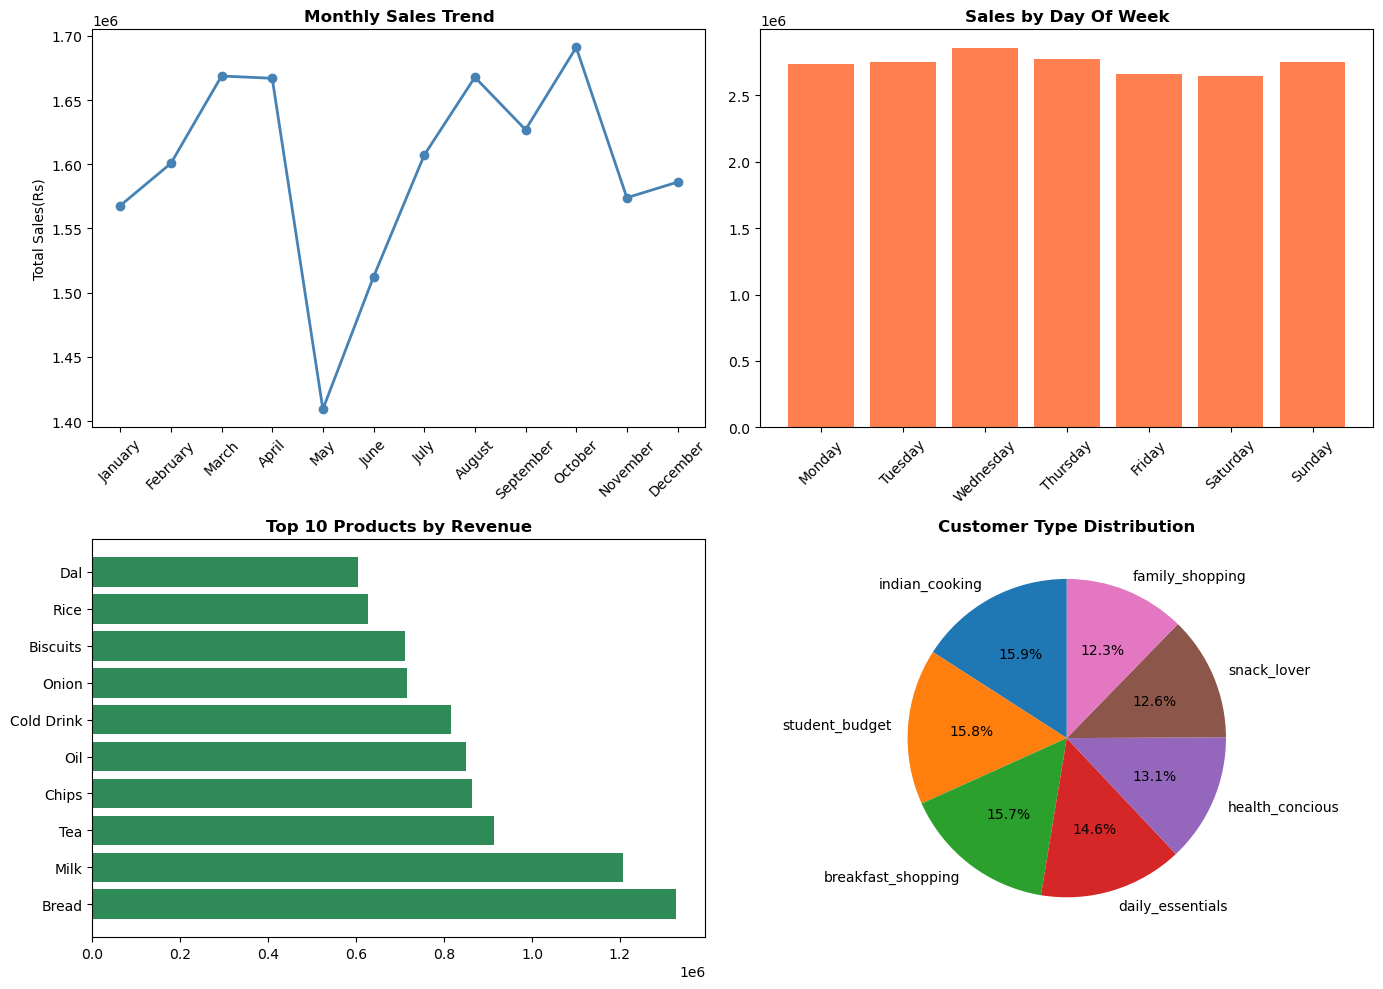

charts saved


In [31]:
#visualize sales trend
fig,axes=plt.subplots(2,2,figsize=(14,10))
#chart1:Monthly sales
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
monthly=df_clean.groupby('Month')['TotalAmount'].sum().reindex(month_order)
axes[0,0].plot(range(12),monthly.values,marker='o',color='steelblue',linewidth=2)
axes[0,0].set_xticks(range(12))
axes[0,0].set_xticklabels(month_order,rotation=45)
axes[0,0].set_title("Monthly Sales Trend",fontweight="bold")
axes[0,0].set_ylabel("Total Sales(Rs)")
#chart2:Sales by days of week
day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily=df_clean.groupby('DayOfWeek')['TotalAmount'].sum().reindex(day_order)
axes[0,1].bar(day_order,daily.values,color='coral')
axes[0,1].set_title("Sales by Day Of Week",fontweight="bold")
axes[0,1].set_xticklabels(day_order,rotation=45)
#chart3:Top 10 product by revenue
top_revenue=df_clean.groupby('Product')['TotalAmount'].sum().nlargest(10)
axes[1,0].barh(top_revenue.index,top_revenue.values,color='seagreen')
axes[1,0].set_title('Top 10 Products by Revenue',fontweight='bold')
#chart4:Customer Type Distribution
customer_type=df_clean['CustomerType'].value_counts()
axes[1,1].pie(customer_type.values,labels=customer_type.index,autopct='%1.1f%%',startangle=90)
axes[1,1].set_title('Customer Type Distribution',fontweight='bold')
plt.tight_layout()
plt.savefig('cognicart/outputs/week2_sales_trends.png',dpi=150)
plt.show()
print("charts saved")


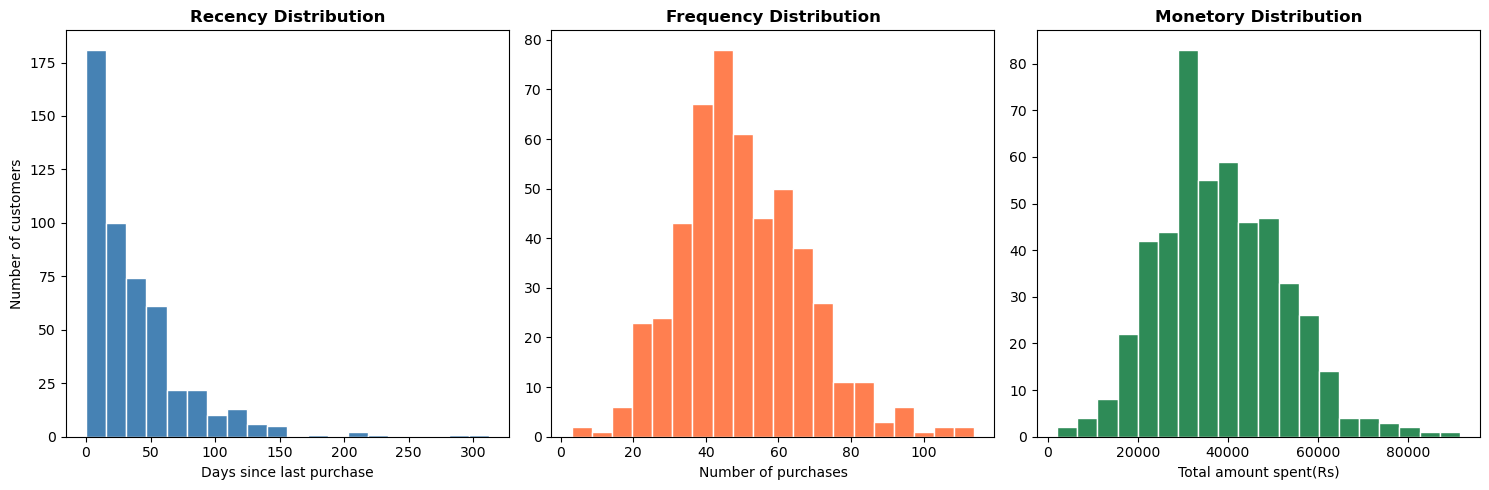

In [33]:
#RFM visualization
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,3,figsize=(15,5))
#Recency distribution
axes[0].hist(rfm['Recency'],bins=20,color='steelblue',edgecolor='white')
axes[0].set_title('Recency Distribution',fontweight='bold')
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Number of customers')
#Frequency Distribution
axes[1].hist(rfm['Frequency'],bins=20,color='coral',edgecolor='white')
axes[1].set_title('Frequency Distribution',fontweight='bold')
axes[1].set_xlabel('Number of purchases')
#Monetory distribution
axes[2].hist(rfm['Monetory'],bins=20,color='seagreen',edgecolor='white')
axes[2].set_title('Monetory Distribution',fontweight='bold')
axes[2].set_xlabel('Total amount spent(Rs)')
plt.tight_layout()
plt.savefig('cognicart/outputs/week2_rfm.png',dpi=150)
plt.show()
                  
                  
                  

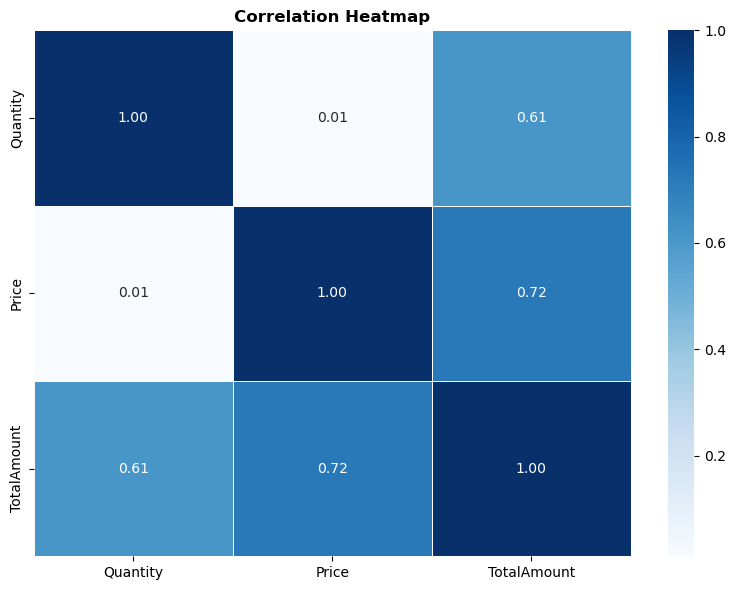

Correlation heatmap saved


In [37]:
#correlation heatmap
#select only number columns for correlation
numeric_cols=df_clean[['Quantity','Price','TotalAmount']]
#calculate correlation
correlation=numeric_cols.corr()
#Draw heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            linewidths=0.5)
plt.title('Correlation Heatmap',fontweight='bold')
plt.tight_layout()
plt.savefig('cognicart/outputs/week2_correlation.png',dpi=150)
plt.show()
print('Correlation heatmap saved')

In [41]:
#create basket format for MBA
#group items by transactionID
basket=df_clean.groupby('TransactionID')['Product'].apply(list).reset_index()
basket.columns=['TransactionID','Items']
print('Basket format created')
print(f'Total transactions"{len(basket)}')
print('Sample baskets:')
print(basket.head(5))
#save basket format
basket.to_csv('cognicart/data/cleaned/basket_format.csv',index=False)
print("Basket format saved!")

Basket format created
Total transactions"25012
Sample baskets:
   TransactionID          Items
0              1        [Chips]
1              2       [Coffee]
2              3      [Popcorn]
3              4   [Cold Drink]
4              5  [Tomatosauce]
Basket format saved!


In [47]:
print('='*50)
print('WEEK2 COMPLETED')
print('='*50)
print(f'Total transactions:{df_clean['TransactionID'].nunique():,}')
print(f'Total customers:{df_clean['Customer_ID'].nunique():,}')
print(f'Total producrs:{df_clean['Product'].nunique():,}')
print(f'Total revenue: Rs{df_clean['TotalAmount'].sum():,.2f}')
print(f'Average basket size:{df_clean.groupby('TransactionID')["Product"].count().mean():.1f}items')
print()
print('Files Saved:')
print('cognicart/data/cleaned/supermarket_clean.csv')
print('cognicart/data/cleaned/rfm_table.csv')
print('cognicart/data/cleaned/basket_format.csv')
print('cognicart/outputs/week2_sales_trends.png')
print('cognicart/outputs/week2_rfm.png')
print('cognicart/outputs/week2_correlation.png')
print()
print('Next week:classical MBA using FP-Growth')


WEEK2 COMPLETED
Total transactions:25,012
Total customers:500
Total producrs:43
Total revenue: Rs19,178,466.02
Average basket size:1.0items

Files Saved:
cognicart/data/cleaned/supermarket_clean.csv
cognicart/data/cleaned/rfm_table.csv
cognicart/data/cleaned/basket_format.csv
cognicart/outputs/week2_sales_trends.png
cognicart/outputs/week2_rfm.png
cognicart/outputs/week2_correlation.png

Next week:classical MBA using FP-Growth
